# Loss curves visualisation 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    "font.size": 12,              # base font size
    "axes.titlesize": 14,         # title font
    "axes.labelsize": 13,         # x and y labels
    "xtick.labelsize": 11,        # x ticks
    "ytick.labelsize": 11,        # y ticks
    "legend.fontsize": 11,        # legend
})

#plt.rcParams['figure.constrained_layout.use'] = True

In [3]:
date = '26_05_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

In [4]:
v_loss = np.load(path + "/val_loss.npy")
t_loss = np.load(path + "/train_loss.npy")
lr = np.load(path + "/lr.npy")

In [5]:
v_loss.min()

0.0018739780574840979

In [6]:
x = pd.DataFrame(v_loss)
min_value = x.min().iloc[0]          # minimal value
min_index = x.idxmin().iloc[0] 
print(min_value)
print(min_index)

NameError: name 'pd' is not defined

In [ ]:
len(v_loss)

In [ ]:
#color palette
CB_color_cycle = ["#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

In [ ]:
plt.plot(np.log(t_loss), color=CB_color_cycle[1], linewidth=2.5)
plt.plot(np.log(v_loss), color=CB_color_cycle[2], linewidth=2.5)

plt.title('Model Loss', size=20)
plt.ylabel('ln(loss)', size=20)
plt.xlabel('Epoch', size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(['Train', 'Validation', 'Best Model'], loc='upper right', fontsize=18)

plt.savefig(path + '/loss_curves_' + date + '.png', bbox_inches='tight')
plt.savefig(path + '/loss_curves_' + date + '.svg', format='svg',transparent=True, bbox_inches='tight')
plt.show()


#plt.savefig(x+'/abeta_cnn_loss_'+x+'.png')
#plt.savefig(x+'/abeta_cnn_loss_'+x+'.svg', format="svg")


In [ ]:
v_loss

In [7]:
v_loss.min()

0.0018739780574840979

In [8]:
t_loss

array([0.0089082 , 0.00409967, 0.00373237, 0.00351852, 0.00335869,
       0.00321484, 0.00309254, 0.00298987, 0.00290028, 0.00282248,
       0.00275901, 0.00270071, 0.00264791, 0.00260139, 0.00256227,
       0.00252082, 0.00248698, 0.00245625, 0.00242855, 0.0024051 ,
       0.0023819 , 0.0023637 , 0.00234456, 0.00232814, 0.0023124 ,
       0.00229865, 0.00228614, 0.00227554, 0.00226525, 0.00225505,
       0.00224797, 0.00223619, 0.00222783, 0.00222074, 0.00221145,
       0.00220765, 0.00219857, 0.00219262, 0.00218821, 0.00218226,
       0.0021785 , 0.00217433, 0.0021678 , 0.00216437, 0.00215894,
       0.00215476, 0.00215236, 0.00214839, 0.00214438, 0.0021409 ,
       0.00213945, 0.00213576, 0.00213214, 0.0021288 , 0.00212828,
       0.00212359, 0.00212123, 0.00211776, 0.00211581, 0.00211353,
       0.00211035, 0.00210945, 0.0021057 , 0.00210372, 0.00210042,
       0.00210015, 0.00209609, 0.00209487, 0.00209264, 0.00208969,
       0.00208864, 0.00208702, 0.0020849 , 0.00208263, 0.00208

# Reconstruction visualisation

In [9]:
from addl_models_bimodel_pytorch import VAE_1modality_PET

import pandas as pd
import nibabel as nib

import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
#from torchvision.utils import save_image

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import seaborn as sns

#import image_similarity_measures.evaluate as evaluate

[NbConvertApp] Converting notebook addl_models_bimodel_pytorch.ipynb to script
[NbConvertApp] Writing 51888 bytes to addl_models_bimodel_pytorch.py


# SSIM - sensitive to noise
Structural Similar Index Measure (SSIM) quantifies image quality degradation caused by processing, such as data compression, or by losses in data transmission. SSIM is based on visible structures in the image. In order words SSIM actually measures the perceptual difference between two similar images. The algorithm does not judge which of the two is better. However, that can be inferred from knowing which is the original image and which has been subjected to additional processing, such as data compression. The SSIM value is between −1 and 1 with 1 indicating perfect structural similarity.



In [10]:
#meta2=  pd.read_csv(path + '/metafile_shuffled_'+ date+'.csv')
meta2=  pd.read_csv(path + '/metafile_shuffled_'+ date+'.csv')

In [11]:
meta2.Project.value_counts()

ADNI    1782
A4      1328
Name: Project, dtype: int64

In [12]:
# Prep brain mask
brain_mask = nib.load('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz').get_fdata()
brain_mask[brain_mask != 0] = 1


In [13]:
#split data on train and test subsets
train_size = 0.8
train_end = int(len(meta2)*train_size)

data_train = meta2[:train_end]
data_test = meta2[train_end:]
# create dictionaries with info for generator
data_partition = dict()
#abeta_labels = dict()
#abeta_all = dict()

t = int(0.8*np.shape(data_train)[0]) #!!
v = int(0.2*np.shape(data_train)[0]) 
#DATADIR = r"/csc/epitkane/data/ADNI/AD_DL_03_11_2021/"

# check the path 
data_partition['train'] = meta2.loc[:t,:].reset_index(drop=True) #!!
data_partition['validation'] = meta2.loc[t+1:train_end,:].reset_index(drop=True) #!!
data_partition['test'] = meta2.loc[train_end+1:,:].reset_index(drop=True) #!!

data_partition['all'] = meta2.loc[:,:].reset_index(drop=True) #!!


In [14]:
data_partition['validation'].iloc[0,:]

Unnamed: 0                                                           1991
Project                                                              ADNI
Phase                                                              ADNI 2
Sex                                                                     F
Weight                                                               83.5
Research.Group                                                        SMC
VISCODE                                                               v03
Study.Date                                                      5/09/2013
Age                                                                  79.1
Modality                                                              PET
Description                   AV45 Co-registered, Averaged <- 3D_IT3 AV45
Imaging.Protocol                                       GE MEDICAL SYSTEMS
Image.Data.ID                                                     I373824
modality_subtype                      

In [15]:
stat = np.load("/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/stats_train.npz")
p_quant90 = stat['p_quant90']
m_quant90 = stat['m_quant90']

p_quant95 = stat['p_quant95']
m_quant95 = stat['m_quant95']

p_quant99 = stat['p_quant99']
m_quant99 = stat['m_quant99']

p_quant999 = stat['p_quant999']
m_quant999 = stat['m_quant999']

p_std = stat['p_std']
m_std = stat['m_std']

p_mean_clip = stat['p_mean_clip']
m_mean_clip = stat['m_mean_clip']
p_std_clip = stat['p_std_clip']
m_std_clip = stat['m_std_clip']

p_min_clip = stat['p_mim_clip']
m_min_clip = stat['m_min_clip']
p_max_clip = stat['p_max_clip']
m_max_clip = stat['m_max_clip']

In [16]:
stat

In [17]:
#p_quant99 = np.quantile(meta2.pet_max, 0.99)
#m_quant99 = np.quantile(meta2.mri_max, 0.99)

In [18]:
class PETSliceDataset(Dataset):
    def __init__(self, list_IDs_pet, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant999,mri_quant= m_quant999, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        """
        PyTorch Dataset for paired 2D slices of PET and MRI scans.
        """
        self.list_IDs_pet = list_IDs_pet
        #self.list_IDs_mri = list_IDs_mri
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_pet):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        pet_slices = []
        pet_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            pet_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            pet_path = pet_path[0]
            if not isinstance(pet_path, str):  
                print(pet_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(pet_path)}")
                
        
        img_pet = nib.load(pet_path).get_fdata()
        #img_mri = nib.load(mri_path).get_fdata()

            # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            pet_slice = img_pet[slice_num_inimg, :, :]
            #mri_slice = img_mri[slice_num_inimg, :, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                pet_slice *= bm
                #mri_slice *= bm
                    
        elif self.slice_axis == 1:  # Coronal
            pet_slice = img_pet[:, slice_num_inimg, :]
            #mri_slice = img_mri[:, slice_num_inimg, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                pet_slice *= bm
                #mri_slice *= bm
            
        else:  # Axial (default)
            pet_slice = img_pet[:, :, slice_num_inimg]
            #mri_slice = img_mri[:, :, slice_num_inimg]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                pet_slice *= bm
                #mri_slice *= bm

            # Skip slices with NaNs or empty regions
        #if np.isnan(pet_slice).any() and np.isnan(mri_slice).any():
        #    return None, None, None, None 
        #if np.max(pet_slice) == 0 and np.max(mri_slice) == 0:
        #    return None, None, None, None 
            # Skip empty slices
            #if pet_slice.size == 0 or mri_slice.size == 0:
            #    continue  # Skip this slice

            # Normalize if necessary (optional step, currently not applied)
        
        pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant), self.pet_minimum, self.pet_maximum)
        #mri_norm = self.min_max_normalize(np.asarray(mri_slice, dtype=np.float32), float(self.mri_quant999), self.mri_minimum, self.mri_maximum)
        
        pet_norm = np.clip(pet_norm, 0, 1)
            # Stack PET and MRI as channels
        #input_2ch = np.stack([pet_norm, mri_norm], axis=0)
            #print(input_2ch.shape) [2,100,200]

            #batch_data.append(input_2ch)  # Store the correct 2-channel data
        #pet_ids.append(pet_path)
        #mri_ids.append(mri_path)
            #print(f"pet_slice shape: {pet_slice.shape}, mri_slice shape: {mri_slice.shape}")

        # Convert to NumPy arrays
        
        batch_data = np.array(pet_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, pet_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        pet_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, pet_ids, slice_n = self.__data_generation([(pet_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)


        return { 'image': X, 'pet_ID': pet_ids, 'slice_number': slice_n }

    #def min_max_normalize(image, min_val, max_val):
    #    return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero

    def quantile_norm(self, image, quantile, mean, std):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        return image
    def min_max_normalize(self,image,quantile, min_val, max_val):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 0, quantile)  # Clip values above quantile
        return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero


In [19]:
class MRISliceDataset(Dataset):
    def __init__(self, list_IDs_mri, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant99,mri_quant = m_quant99, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        """
        PyTorch Dataset for paired 2D slices of PET and MRI scans.
        """
        #self.list_IDs_pet = list_IDs_pet
        self.list_IDs_mri = list_IDs_mri
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_mri):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        mri_slices = []
        mri_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            mri_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            mri_path = mri_path[0]
            if not isinstance(mri_path, str):  
                print(mri_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(mri_path)}")
                
        
        #img_pet = nib.load(pet_path).get_fdata()
        img_mri = nib.load(mri_path).get_fdata()

            # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            #pet_slice = img_pet[slice_num_inimg, :, :]
            mri_slice = img_mri[slice_num_inimg, :, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                #pet_slice *= bm
                mri_slice *= bm
                    
        elif self.slice_axis == 1:  # Coronal
            #pet_slice = img_pet[:, slice_num_inimg, :]
            mri_slice = img_mri[:, slice_num_inimg, :]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                #pet_slice *= bm
                mri_slice *= bm
            
        else:  # Axial (default)
            #pet_slice = img_pet[:, :, slice_num_inimg]
            mri_slice = img_mri[:, :, slice_num_inimg]
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                #pet_slice *= bm
                mri_slice *= bm

            # Normalize if necessary (optional step, currently not applied)
        
        #pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant999), self.pet_minimum, self.pet_maximum)
        mri_norm = self.min_max_normalize(np.asarray(mri_slice, dtype=np.float32), float(self.mri_quant))
        
        #pet_norm = np.clip(pet_norm, 1e-7, 1 - 1e-7) #???or just to 0 and 1?
        mri_norm = np.clip(mri_norm, 1e-7, 1 - 1e-7) #???or just to 0 and 1?
            
            # Stack PET and MRI as channels
        #input_2ch = np.stack([pet_norm, mri_norm], axis=0)
            #print(input_2ch.shape) [2,100,200]

            #batch_data.append(input_2ch)  # Store the correct 2-channel data
        #pet_ids.append(pet_path)
        #mri_ids.append(mri_path)
            #print(f"pet_slice shape: {pet_slice.shape}, mri_slice shape: {mri_slice.shape}")

        # Convert to NumPy arrays
        
        batch_data = np.array(mri_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, mri_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        mri_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, mri_ids, slice_n = self.__data_generation([(mri_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)


        return { 'image': X, 'mri_ID': mri_ids, 'slice_number': slice_n }

    #def min_max_normalize(image, min_val, max_val):
    #    return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero

    def quantile_norm(self, image, quantile, mean, std):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        return image
    def min_max_normalize(self,image,quantile, epsilon=1e-6):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 1e-7, quantile)  # Clip values above quantile
        #image = np.log1p(image)  # or np.log(data + ε)
        #if image.max() - image.min() < epsilon:
        #    return np.zeros_like(image)  # Avoid division by zero
        #image = np.sqrt(image)
        #return (image - np.sqrt(1e-7)) / (np.sqrt(quantile) - np.sqrt(1e-7))
        #return (image - np.log1p(1e-7)) / (np.log1p(quantile) - np.log1p(1e-7))
        return (image - image.min())/(quantile - image.min() + 1e-8)  # Avoid division by zero


In [20]:
data_partition['all'].columns

Index(['Unnamed: 0', 'Project', 'Phase', 'Sex', 'Weight', 'Research.Group',
       'VISCODE', 'Study.Date', 'Age', 'Modality', 'Description',
       'Imaging.Protocol', 'Image.Data.ID', 'modality_subtype', 'PATH',
       'MRI_subID', 'MRI_Modality', 'MRI_Research.Group', 'MRI_Age',
       'MRI_VISCODE', 'MRI_studydate', 'MRI_Description',
       'MRI_Imaging.protocol', 'MRI_Type', 'MRI_ID', 'MRI_PATH',
       'PET_PATH_normalised', 'MRI_PATH_registered', 'pet_min', 'pet_max',
       'pet_90q', 'pet_95q', 'pet_99q', 'pet_999q', 'mri_min', 'mri_max',
       'mri_90q', 'mri_95q', 'mri_99q', 'mri_999q'],
      dtype='object')

In [21]:
data_partition['test']['PET_PATH_normalised'][100]

'/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/I508693_normalised.nii'

In [42]:
# creating PET datasets 
train_dataset = PETSliceDataset(list_IDs_pet = data_partition['train']['PET_PATH_normalised'], brain_mask = brain_mask)

validation_dataset = PETSliceDataset(list_IDs_pet = data_partition['validation']['PET_PATH_normalised'], brain_mask = brain_mask)

test_dataset = PETSliceDataset(list_IDs_pet = data_partition['test']['PET_PATH_normalised'][19:20], brain_mask = brain_mask) #99:100 19:20


In [90]:
'''# creating MRI datasets 
train_dataset = MRISliceDataset(list_IDs_mri = data_partition['train']['MRI_PATH_registered'], brain_mask = brain_mask)

validation_dataset = MRISliceDataset(list_IDs_mri = data_partition['validation']['MRI_PATH_registered'], brain_mask = brain_mask)

test_dataset = MRISliceDataset(list_IDs_mri = data_partition['test']['MRI_PATH_registered'], brain_mask = brain_mask)
'''

In [213]:
'''# creating datasets 
train_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['all'][data_partition['all']['Image.Data.ID'] == 'I1324526']['PET_PATH_normalised'], brain_mask = brain_mask)

validation_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['all'][data_partition['all']['Image.Data.ID'] == 'I1324667']['PET_PATH_normalised'], brain_mask = brain_mask)

test_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['all'][data_partition['all']['Image.Data.ID'] == 'I420682']['PET_PATH_normalised'], brain_mask = brain_mask)
'''

"# creating datasets \ntrain_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['all'][data_partition['all']['Image.Data.ID'] == 'I1324526']['PET_PATH_normalised'], brain_mask = brain_mask)\n\nvalidation_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['all'][data_partition['all']['Image.Data.ID'] == 'I1324667']['PET_PATH_normalised'], brain_mask = brain_mask)\n\ntest_dataset = PETMRISliceDataset(list_IDs_pet = data_partition['all'][data_partition['all']['Image.Data.ID'] == 'I420682']['PET_PATH_normalised'], brain_mask = brain_mask)\n"

In [43]:
# creating dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=2,
                        shuffle=False, num_workers=0)

validation_dataloader = DataLoader(validation_dataset, batch_size=2,
                        shuffle=False, num_workers=0)

test_dataloader = DataLoader(test_dataset, batch_size=182,
                        shuffle=False, num_workers=0)

In [44]:
#model_up = CCVAE(60*10*12*9, latent_size =500, class_size =3)
model_up=torch.load(path+"/best_model.pth",map_location=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))
model_up.eval()

VAE_1modality_PET(
  (conv): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense_mean): Linear(in_features=262144, out_features=64, bias=True)
  (dense_log_var): Linear(in_features=262144, out_features=64, bias=True)
  (dense): Linear(in_features=64, out_features=262144, bias=True)
  (deconv): Sequential(
    (0): DeconvBlock(
      (deconv): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (1): DeconvBlock(
      (deconv): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (2): DeconvBlock(

In [45]:
for batch_idx, data in enumerate(test_dataloader):
    print(data['image'].shape)

torch.Size([182, 1, 182, 218])


In [46]:
# Assuming train_dataloader is already defined
def scans_reconstruction(dataloader):
    for batch_idx, data in enumerate(dataloader):
        #print(batch_idx)
    
        # Store the original data batch (image)
        data_batch_train = data['image'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")
        #print(data['pet_ID'])
        # Store the data batch for training
        #data_batch_train = orig_scan  # This stores the image batch for further processing
        
        # Perform image reconstruction using the model
        image_recon_train = model_up(data_batch_train)
        
        # Append the data batch and image reconstructions to the lists
        #orig_scan.append(data_batch_train.cpu())  # Move back to CPU for storage
        #image_reconstructions.append(image_recon_train.cpu())  # Similarly, store the reconstructions
        if batch_idx == 0:
            orig_scan = data_batch_train.detach().numpy()
            recon_scan = image_recon_train[0].detach().numpy()
        else:
            orig_scan = np.concatenate([orig_scan, data_batch_train.detach().numpy()], axis=0)
            recon_scan = np.concatenate([recon_scan, image_recon_train[0].detach().numpy()], axis=0)
        
    
        # Optional: Break the loop after 92 batches (if needed)
        if batch_idx >= 90:  # To capture the first 91 batches (0-indexed)
            break
    return orig_scan, recon_scan

# Now you have data_batches and image_reconstructions lists


In [47]:
#train_or, train_rec = scans_reconstruction(train_dataloader)
#val_or, val_rec = scans_reconstruction(validation_dataloader)
test_or, test_rec = scans_reconstruction(test_dataloader)

In [73]:
test_or.shape

(182, 1, 182, 218)

In [59]:
test_rec.shape

(182, 1, 182, 218)

In [31]:
test_rec[:,0,:,:].flatten().min()

0.0

(array([5.393937e+06, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 1.430000e+02, 7.230000e+02,
        1.806000e+03, 3.281000e+03, 5.043000e+03, 6.841000e+03,
        9.339000e+03, 1.049200e+04, 1.153200e+04, 1.344700e+04,
        1.651800e+04, 1.874400e+04, 2.116400e+04, 2.433400e+04,
        2.571100e+04, 2.719300e+04, 2.852000e+04, 2.972300e+04,
        3.046600e+04, 3.023000e+04, 3.036400e+04, 3.049400e+04,
        3.145600e+04, 3.230800e+04, 3.361700e+04, 3.502200e+04,
        3.587100e+04, 3.677800e+04, 3.745900e+04, 3.798000e+04,
        3.865800e+04, 3.867100e+04, 3.905000e+04, 3.878000e+04,
        3.833500e+04, 3.716600e+04, 3.657500e+04, 3.565100e+04,
        3.469900e+04, 3.452000e+04, 3.359900e+04, 3.332500e+04,
        3.230500e+04, 3.144700e+04, 3.015400e+04, 2.900100e+04,
        2.796100e+04, 2.721200e+04, 2.630300e+04, 2.572600e+04,
        2.535600e+04, 2.443200e+04, 2.37

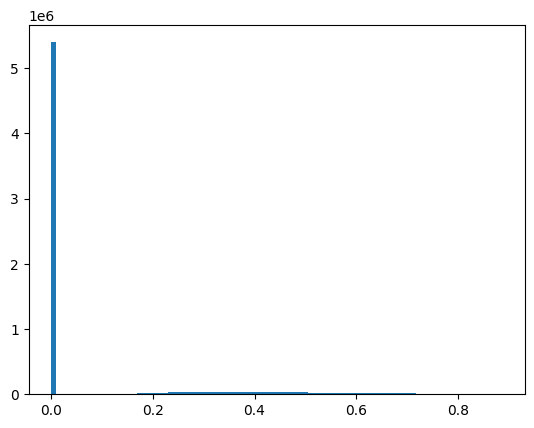

In [34]:
plt.hist(train_or[:,0,:,:].flatten(), bins = 100)

(array([5.361332e+06, 2.659000e+03, 2.844000e+03, 2.798000e+03,
        2.796000e+03, 2.797000e+03, 3.159000e+03, 3.187000e+03,
        3.311000e+03, 3.406000e+03, 3.713000e+03, 4.072000e+03,
        4.560000e+03, 5.398000e+03, 6.265000e+03, 7.460000e+03,
        9.131000e+03, 1.072300e+04, 1.213100e+04, 1.368900e+04,
        1.567600e+04, 1.787400e+04, 1.968900e+04, 2.149200e+04,
        2.368700e+04, 2.561000e+04, 2.740800e+04, 2.816800e+04,
        2.927400e+04, 3.003800e+04, 3.110100e+04, 3.178200e+04,
        3.319800e+04, 3.452800e+04, 3.584600e+04, 3.666100e+04,
        3.829600e+04, 3.864700e+04, 3.962300e+04, 3.955700e+04,
        3.973400e+04, 3.913200e+04, 3.853800e+04, 3.819400e+04,
        3.770800e+04, 3.702700e+04, 3.673900e+04, 3.591200e+04,
        3.509200e+04, 3.463300e+04, 3.388200e+04, 3.300400e+04,
        3.240500e+04, 3.118600e+04, 3.043200e+04, 2.928600e+04,
        2.866400e+04, 2.774800e+04, 2.676400e+04, 2.617300e+04,
        2.561100e+04, 2.491000e+04, 2.39

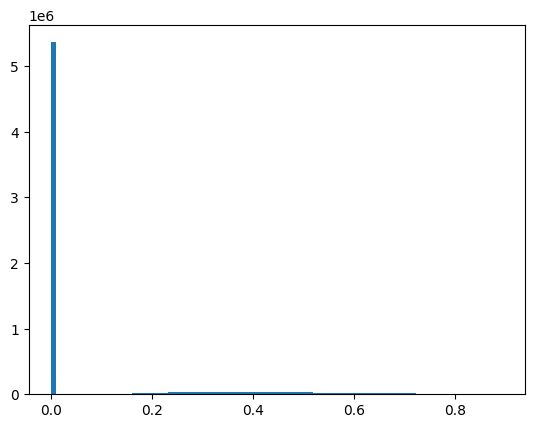

In [35]:
plt.hist(train_rec[:,0,:,:].flatten(), bins = 100)

(-0.5, 181.5, 217.5, -0.5)

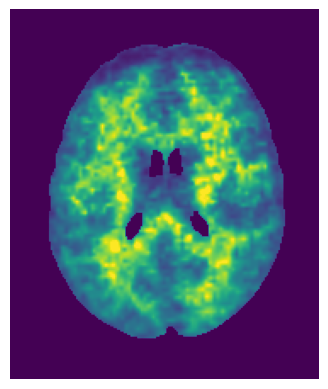

In [60]:
plt.imshow(np.rot90(test_or[90,0,:,:]))
plt.axis('off')

(-0.5, 181.5, 217.5, -0.5)

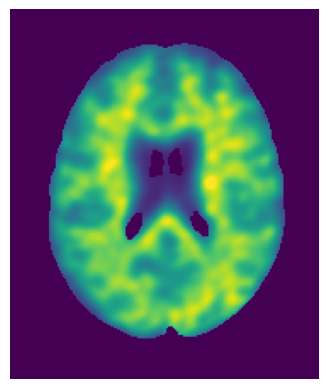

In [74]:
plt.imshow(np.rot90(test_or[90,0,:,:]))
plt.axis('off')

(-0.5, 181.5, 217.5, -0.5)

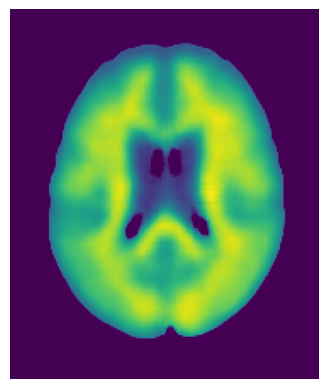

In [75]:
plt.imshow(np.rot90(test_rec[90,0,:,:]))
plt.axis('off')

(-0.5, 181.5, 217.5, -0.5)

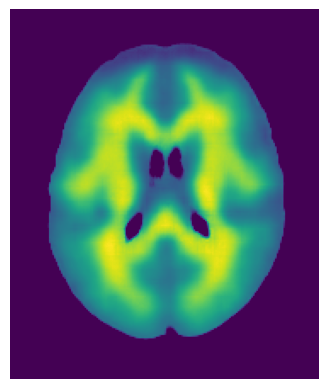

In [39]:
plt.imshow(np.rot90(test_rec[90,0,:,:]))
plt.axis('off')

In [40]:
'''for batch_idx, data in enumerate(train_dataloader):
    print(batch_idx)
    orig_scan = 
    while batch_idx < 92:
        #cond = data['condition'].type(torch.FloatTensor).to('cpu')
        data_batch_train = data['image'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")
        break
image_recon_train = model_up(data_batch_train)

for batch_idx, data in enumerate(validation_dataloader):
    print(batch_idx)
    if batch_idx == 0:
        #cond = data['condition'].type(torch.FloatTensor).to('cpu')
        data_batch_val = data['image'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")
        break
image_recon_val= model_up(data_batch_val)

for batch_idx, data in enumerate(test_dataloader):
    print(batch_idx)
    if batch_idx == 0:
        #cond = data['condition'].type(torch.FloatTensor).to('cpu')
        data_batch_test = data['image'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")
        break
image_recon_test = model_up(data_batch_test)'''

'for batch_idx, data in enumerate(train_dataloader):\n    print(batch_idx)\n    orig_scan = \n    while batch_idx < 92:\n        #cond = data[\'condition\'].type(torch.FloatTensor).to(\'cpu\')\n        data_batch_train = data[\'image\'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")\n        break\nimage_recon_train = model_up(data_batch_train)\n\nfor batch_idx, data in enumerate(validation_dataloader):\n    print(batch_idx)\n    if batch_idx == 0:\n        #cond = data[\'condition\'].type(torch.FloatTensor).to(\'cpu\')\n        data_batch_val = data[\'image\'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")\n        break\nimage_recon_val= model_up(data_batch_val)\n\nfor batch_idx, data in enumerate(test_dataloader):\n    print(batch_idx)\n    if batch_idx == 0:\n        #cond = data[\'condition\'].type(torch.FloatTensor).to(\'cpu\')\n        data_batch_test = data[\'image\'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.i

In [41]:
# what do I need for better understanding of the model performance?
# within model: reconstruction quality for random scan from test dataset,validation dataset and test dataset 
# between models: pick up the scan that will be quality check for the model. Should I exclude this scan from model's training at all?

In [42]:
#Within the model
# SSIM between reconstructed and original scans - box plot for train, val and test datasets + Plot with several slices
# SSIM between 3D reconstruction and original scan

In [48]:
ssim_slice_train = []
ssim_slice_val = []
ssim_slice_test = []
def ssim_function(original_img, recon_img):
    pet = []
    mri = []
    for i in range(original_img.shape[0]):
        #data_range_pet = max(original_img[i][0].max() - original_img[i][0].min(), 
        #                 recon_img[i][0].max() - recon_img[i][0].min())
        
        pet.append(float(ssim(original_img[i][0], recon_img[i][0], data_range=1)))

        '''data_range_mri = max(original_img[i][1].max() - original_img[i][1].min(), 
                         recon_img[i][1].max() - recon_img[i][1].min())
        
        mri.append(float(ssim(original_img[i][1], recon_img[i][1], data_range=data_range_mri)))'''
    return pet


In [49]:
def psnr_function(original_img, recon_img):
    pet = []
    mri = []
    for i in range(original_img.shape[0]):
        #data_range_pet = max(original_img[i][0].max() - original_img[i][0].min(), 
        #                 recon_img[i][0].max() - recon_img[i][0].min())
        
        pet.append(float(psnr(original_img[i][0], recon_img[i][0], data_range=1)))

        '''data_range_mri = max(original_img[i][1].max() - original_img[i][1].min(), 
                         recon_img[i][1].max() - recon_img[i][1].min())
        
        mri.append(float(psnr(original_img[i][1], recon_img[i][1], data_range=data_range_mri)))'''
    return pet

In [50]:
psnr(train_or[0][0], train_rec[0][0], data_range=1)

NameError: name 'train_or' is not defined

In [ ]:
test_or.max()

In [129]:
test_rec.max()

0.97881126

In [51]:
#train_pet_ssim = ssim_function(train_or,train_rec)
#val_pet_ssim =ssim_function(val_or,val_rec)
test_pet_ssim =ssim_function(test_or,test_rec)

In [52]:
#train_pet_psnr = psnr_function(train_or,train_rec)
#val_pet_psnr =psnr_function(val_or,val_rec)
test_pet_psnr =psnr_function(test_or,test_rec)

In [50]:
len(train_pet_psnr)

182

In [143]:
'''def plot_slices(original_scan, reconstruction_scan,ssim_pet,psnr_pet, name):
    fig = plt.figure(figsize=(15,10))
    index1 = [1,2,3,4]
    index2 = [5,6,7,8]
    index3 = [9,10,11,12]
    index4 = [13,14,15,16]
    start = 0
    for num, i in enumerate([45,90,125]):
        
        fig.add_subplot(4, 4, index1[num])
        plt.imshow(np.rot90(original_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        
        fig.add_subplot(4, 4, index2[num])
        plt.imshow(np.rot90(reconstruction_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        plt.text(0.95, 0.05, "SSIM="+str(round(ssim_pet[i],4)), fontsize=12, color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        plt.text(0.95, 0.85, "PSNR="+str(round(psnr_pet[i],4)), fontsize=12, color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        
        
        plt.subplots_adjust(wspace=-0.7, hspace=0.2) 
        
        #print(ssim_pet[i])
        plt.axis('off')
        plt.savefig(path+name+date+'.png', bbox_inches='tight')  # Save as PNG with 300 DPI
        plt.savefig(path+name+date+'.svg', format='svg',transparent=True, bbox_inches='tight')  '''

In [81]:
test_pet_psnr

[inf,
 41.73492803040471,
 45.184171708052,
 40.46314009547623,
 40.84627627535141,
 46.19224920199163,
 38.01571441229204,
 41.15330592465562,
 37.074916594623566,
 41.87868452736499,
 38.320179587211626,
 35.48255484919236,
 35.70739712899847,
 36.29616965007951,
 35.79380945577876,
 36.63211530930377,
 35.44452799296403,
 35.699419535871385,
 36.82256243988487,
 36.32024603050723,
 34.14066399406749,
 35.039418937891455,
 35.975565477043766,
 33.57549049215609,
 32.776426328465035,
 31.634542512631953,
 31.114618172449426,
 29.74770313868788,
 29.36208407552723,
 29.17574958701943,
 28.876401368084537,
 28.563217667689315,
 28.936034951175053,
 28.686462460878936,
 28.596733686739245,
 29.323191221618735,
 29.036877261376812,
 28.98773836792614,
 28.863498192938657,
 29.20365268420584,
 29.228051571578074,
 29.039702935442993,
 28.869834039898997,
 28.142561526451523,
 28.21833098487437,
 28.103503212937543,
 28.378287339438543,
 28.57254466132694,
 28.043758310338855,
 28.093348830

In [40]:
plt.rcParams.update({
    "font.size": 16,              # base font size
    "axes.titlesize": 16,         # title font
    "axes.labelsize": 18,         # x and y labels
    "xtick.labelsize": 16,        # x ticks
    "ytick.labelsize": 16,        # y ticks
    "legend.fontsize": 15        # legend
})


def plot_slices(original_scan, reconstruction_scan,ssim_pet,psnr_pet, name):
    fig = plt.figure(figsize=(12,6))
    index1 = [1,3]
    index2 = [2,4]
    start = 0
    for num, i in enumerate([45,90]):
        
        fig.add_subplot(2, 2, index1[num])
        plt.imshow(np.rot90(original_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        if index1[num] == 1:
            plt.title('Original scan')
        
        fig.add_subplot(2,2, index2[num])
        plt.imshow(np.rot90(reconstruction_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        plt.text(0.95, 0.05, "SSIM="+str(round(ssim_pet[i],2)), color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        plt.text(0.95, 0.85, "PSNR="+str(round(psnr_pet[i],2)), color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        if index2[num] == 2:
            plt.title('Reconstructed scan')
        
        
        plt.subplots_adjust(wspace=-0.7, hspace=0.2) 
        
        #print(ssim_pet[i])
        plt.axis('off')
        plt.savefig(path+name+date+'.png', bbox_inches='tight')  # Save as PNG with 300 DPI
        plt.savefig(path+name+date+'.svg', format='svg',transparent=True, bbox_inches='tight')  

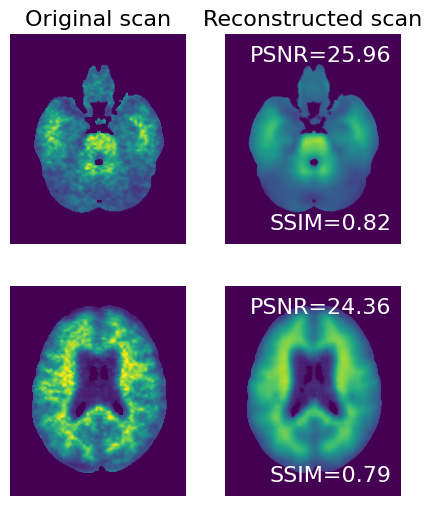

In [41]:
plot_slices(test_or,test_rec,test_pet_ssim,test_pet_psnr,'/slices_recon_test_sample_9siemens')

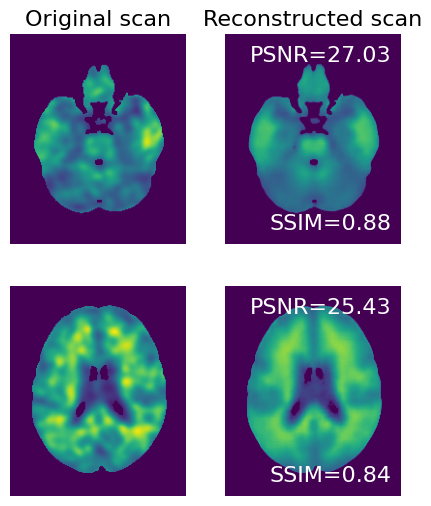

In [53]:
plot_slices(test_or,test_rec,test_pet_ssim,test_pet_psnr,'/slices_recon_test_sample_19philips')

In [103]:
data_partition['test']['Imaging.Protocol'][:1]

0    CPS
Name: Imaging.Protocol, dtype: object

In [104]:
data_partition['test']['Imaging.Protocol'][99:100]

99    NaN
Name: Imaging.Protocol, dtype: object

In [132]:
data_partition['test']['Imaging.Protocol'].value_counts()

GE MEDICAL SYSTEMS         117
Siemens/CTI                 64
SIEMENS                     63
Philips Medical Systems     44
Siemens ECAT                28
CPS                         25
GEMS                         3
Philips                      2
Name: Imaging.Protocol, dtype: int64

In [117]:
data_partition['test'][data_partition['test']['Imaging.Protocol'] == 'SIEMENS']

,Unnamed: 0,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,...,pet_90q,pet_95q,pet_99q,pet_999q,mri_min,mri_max,mri_90q,mri_95q,mri_99q,mri_999q
9,2498,ADNI,ADNI 2,F,51.7,LMCI,v21,6/13/2014,68.5,PET,...,1.412099,1.761126,2.249179,2.624476,0.000000,971.619568,288.703577,381.496474,584.954092,707.650196
17,2506,ADNI,ADNI 2,M,82.6,CN,v03,6/22/2011,66.8,PET,...,1.439296,1.868094,2.396618,2.881977,0.000000,926.496399,253.053830,355.627470,547.617891,692.443367
23,2512,ADNI,ADNI 2,F,83.0,LMCI,v21,6/09/2014,66.6,PET,...,1.490202,1.761669,2.098833,2.490233,0.000000,1109.014038,329.995721,426.531569,696.269891,858.152340
33,2522,ADNI,ADNI 2,M,67.6,EMCI,v21,2/27/2014,79.4,PET,...,1.583454,1.838214,2.149723,2.464836,0.018984,1055.083740,302.498074,333.862379,503.666151,704.741838
77,2566,ADNI,ADNI 2,M,91.4,CN,v21,2/06/2014,83.4,PET,...,1.358459,1.820180,2.494623,3.091804,0.000000,2438.217529,316.515277,456.488251,772.210275,1300.005783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594,3083,ADNI,ADNI 2,F,64.4,CN,v41,9/30/2015,86.4,PET,...,1.235890,1.506596,1.892768,2.258984,0.000000,641.814941,196.886197,288.478558,419.810314,527.193831
599,3088,ADNI,ADNI 2,M,89.8,CN,v21,12/18/2013,75.0,PET,...,1.329427,1.744206,2.343127,2.900078,0.000000,823.851990,285.027795,342.940063,533.008621,656.311716
607,3096,ADNI,ADNI GO,F,69.6,EMCI,bl,10/14/2010,67.9,PET,...,1.474932,1.787350,2.196547,2.581514,0.129376,948.771545,317.969968,351.960306,576.624624,740.470122
612,3101,ADNI,ADNI 2,M,79.1,CN,v21,10/17/2013,77.3,PET,...,1.436579,1.802974,2.325968,2.849329,0.000000,914.058472,263.493375,349.578191,560.702092,713.014957


In [133]:
data_partition['test'][data_partition['test']['Imaging.Protocol'] == 'Philips Medical Systems']

,Unnamed: 0,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,...,pet_90q,pet_95q,pet_99q,pet_999q,mri_min,mri_max,mri_90q,mri_95q,mri_99q,mri_999q
19,2508,ADNI,ADNI GO,F,58.1,MCI,m48,3/31/2011,80.7,PET,...,1.583024,1.820041,2.174238,2.616129,0.000000e+00,8.406024e+02,2.947756e+02,3.356592e+02,4.989850e+02,5.653927e+02
28,2517,ADNI,ADNI 2,F,90.4,SMC,v21,9/08/2015,72.7,PET,...,1.569728,1.813652,2.145944,2.428271,0.000000e+00,4.378896e+03,1.253867e+03,1.885340e+03,2.407799e+03,2.672676e+03
135,2624,ADNI,ADNI 2,M,82.6,EMCI,v03,2/27/2012,75.0,PET,...,1.569264,1.830755,2.120179,2.360135,0.000000e+00,9.847775e+02,2.822102e+02,3.045808e+02,4.430544e+02,5.681518e+02
138,2627,ADNI,ADNI GO,M,83.9,CN,m48,12/03/2010,80.6,PET,...,1.286399,1.434425,1.634434,1.890239,0.000000e+00,9.082083e+02,2.887376e+02,3.275499e+02,4.763829e+02,5.748949e+02
143,2632,ADNI,ADNI 2,M,76.2,EMCI,v21,7/11/2014,70.1,PET,...,1.638856,1.991577,2.406595,2.638441,0.000000e+00,3.725268e+03,1.210750e+03,1.296186e+03,1.832050e+03,2.537625e+03
169,2658,ADNI,ADNI 2,F,100.2,LMCI,v03,9/06/2011,64.8,PET,...,1.594370,1.825933,2.060497,2.338238,0.000000e+00,9.446206e+02,2.491958e+02,4.134097e+02,5.892346e+02,7.264683e+02
174,2663,ADNI,ADNI 2,M,80.1,EMCI,v03,4/04/2012,81.5,PET,...,1.563415,1.784413,2.022103,2.220290,0.000000e+00,1.077756e+03,2.780889e+02,3.316201e+02,5.541253e+02,7.221622e+02
195,2684,ADNI,ADNI GO,M,76.2,CN,m60,4/27/2011,78.5,PET,...,1.237534,1.399208,1.615020,1.818848,0.000000e+00,7.440255e+02,2.590386e+02,2.827899e+02,3.588298e+02,4.854927e+02
203,2692,ADNI,ADNI 2,M,79.6,CN,v11,9/17/2012,82.4,PET,...,1.326550,1.492026,1.690073,1.893938,0.000000e+00,7.841544e+02,2.839935e+02,3.129642e+02,4.510573e+02,5.485088e+02
213,2702,ADNI,ADNI 2,F,45.4,CN,v41,12/09/2015,82.4,PET,...,1.516914,1.855554,2.312234,2.616655,0.000000e+00,1.187803e+03,3.048096e+02,3.774133e+02,6.440226e+02,8.277781e+02


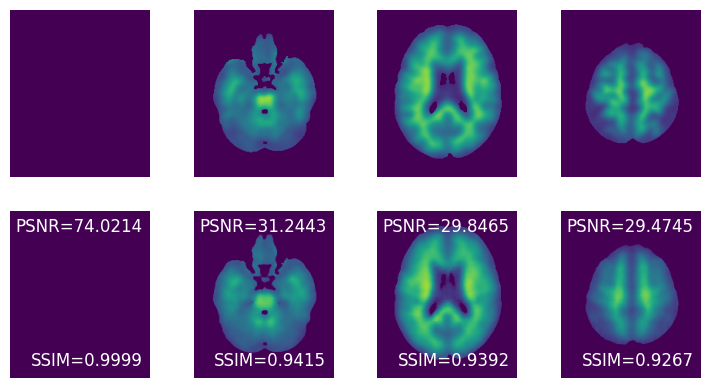

In [145]:
plot_slices(train_or,train_rec,train_pet_ssim,train_pet_psnr,'/slices_recon_train_')

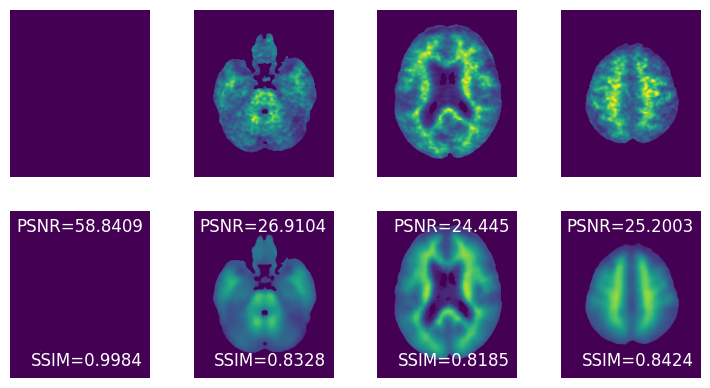

In [146]:
plot_slices(val_or,val_rec,val_pet_ssim,val_pet_psnr,'/slices_recon_val_')

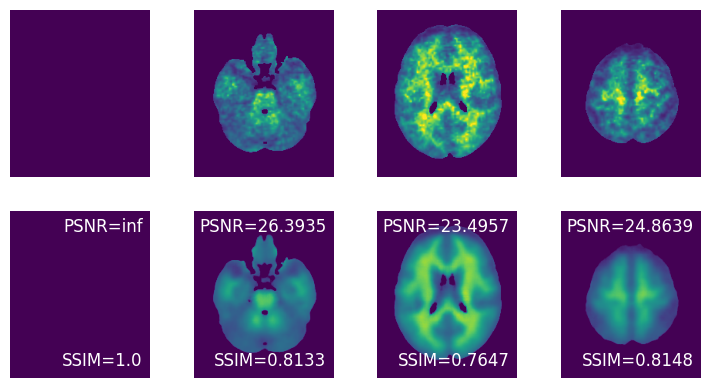

In [147]:
plot_slices(test_or,test_rec,test_pet_ssim,test_pet_psnr,'/slices_recon_test_')

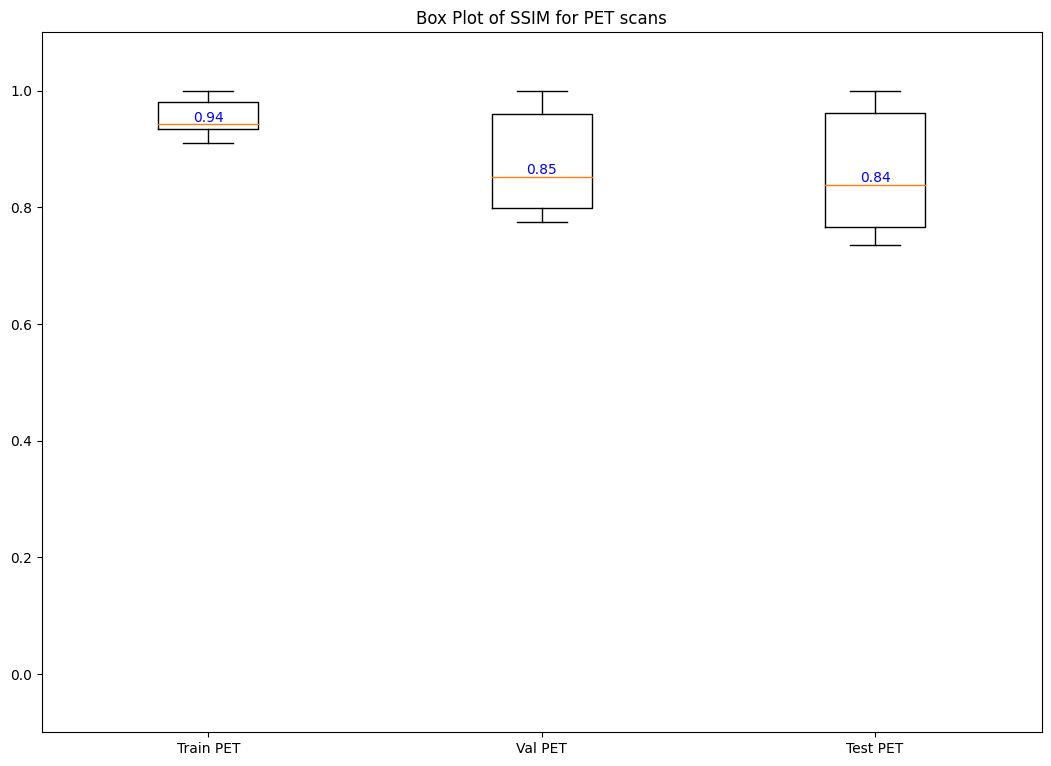

In [63]:
data = [train_pet_ssim, val_pet_ssim, test_pet_ssim]

fig = plt.figure(figsize=(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title('Box Plot of SSIM for PET scans')
# Creating plot
bp = ax.boxplot(data)

# Adding labels to x-axis
ax.set_xticklabels(['Train PET', 'Val PET', 'Test PET'])

# Setting the y-axis range from 0 to 1
ax.set_ylim(-0.1, 1.1)
for i, dataset in enumerate(data, start=1):
    median_value = np.median(dataset)
    # Adding text annotation for the average value on the box plot
    ax.text(i, median_value, f'{median_value:.2f}', ha='center', va='bottom', fontsize=10, color='blue')

# Show the plot

plt.savefig(path+'/SSIM_boxplots_'+date+'.png', bbox_inches='tight') 
plt.show()

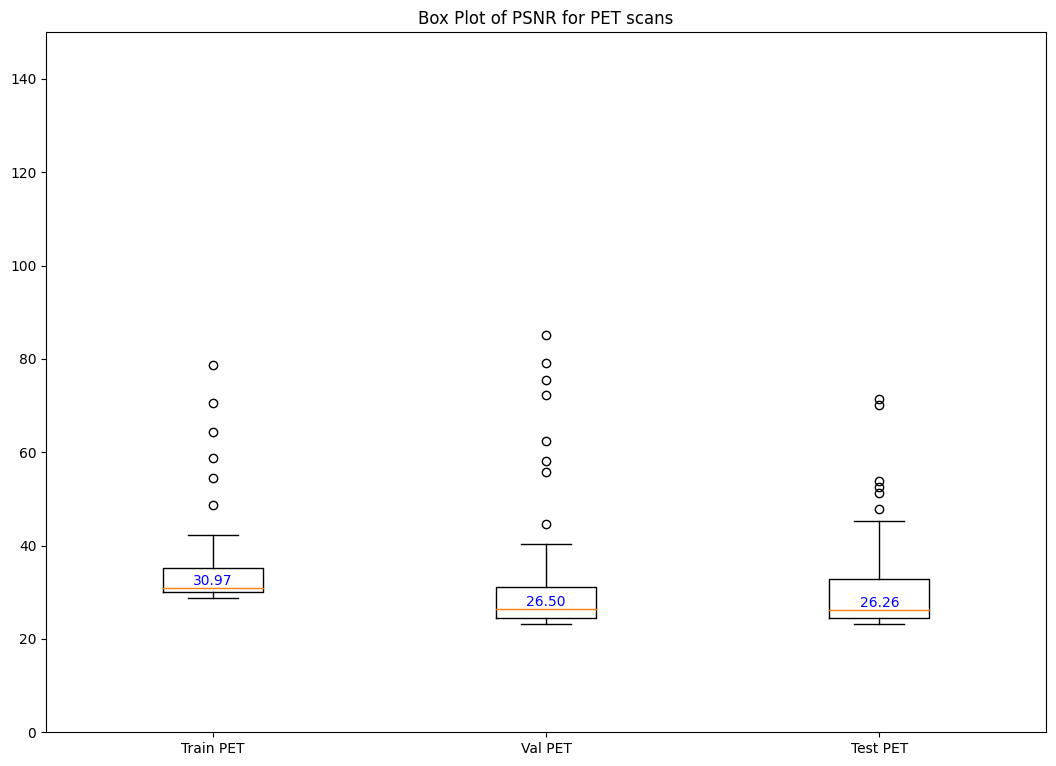

In [64]:
data = [train_pet_psnr, val_pet_psnr, test_pet_psnr]

fig = plt.figure(figsize=(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title('Box Plot of PSNR for PET scans')
# Creating plot
bp = ax.boxplot(data)

# Adding labels to x-axis
ax.set_xticklabels(['Train PET', 'Val PET', 'Test PET'])

# Setting the y-axis range from 0 to 1
ax.set_ylim(0, 150)
for i, dataset in enumerate(data, start=1):
    median_value = np.median(dataset)
    # Adding text annotation for the average value on the box plot
    ax.text(i, median_value, f'{median_value:.2f}', ha='center', va='bottom', fontsize=10, color='blue')

# Show the plot

plt.savefig(path+'/PSNR_boxplots_'+date+'.png', bbox_inches='tight') 
plt.show()

# UMAP 

In [128]:
print('start PCA plotting')
date = '01_04_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

start PCA plotting


In [135]:
import umap
import umap.plot

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/umap/plot.py:29: UserWarning: The umap.plot package requires extra plotting libraries to be installed.
    You can install these via pip using

    pip install umap-learn[plot]

    or via conda using

     conda install pandas matplotlib datashader bokeh holoviews colorcet scikit-image
    
  """


ImportError: umap.plot requires pandas matplotlib datashader bokeh holoviews scikit-image and colorcet to be installed

In [132]:
df_train = pd.read_csv(path + '/latent_features_train_'+ date+'.csv', index_col = 0)
df_validation = pd.read_csv(path + '/latent_features_validation_'+ date+'.csv', index_col = 0)
df_test = pd.read_csv(path + '/latent_features_test_'+ date+'.csv', index_col = 0)




df_all = pd.concat([df_train,df_validation.iloc[:,1:],df_test.iloc[:,1:]], axis = 1)

In [136]:
df_all

,I1324526_normalised.nii_0,I1324526_normalised.nii_1,I1324526_normalised.nii_2,I1324526_normalised.nii_3,I1324526_normalised.nii_4,I1324526_normalised.nii_5,I1324526_normalised.nii_6,I1324526_normalised.nii_7,I1324526_normalised.nii_8,I1324526_normalised.nii_9,...,I347947_normalised.nii_172,I347947_normalised.nii_173,I347947_normalised.nii_174,I347947_normalised.nii_175,I347947_normalised.nii_176,I347947_normalised.nii_177,I347947_normalised.nii_178,I347947_normalised.nii_179,I347947_normalised.nii_180,I347947_normalised.nii_181
0,8.683018,13.684188,13.540447,13.842997,14.160388,14.435659,15.021078,14.546769,12.901215,12.152240,...,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018
1,4.341754,7.393911,7.662460,7.461079,8.108271,8.607652,7.675388,7.474201,5.680021,4.129666,...,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754
2,-3.907818,1.261566,0.883396,0.708285,0.760770,0.719257,0.595988,-0.926509,-5.261401,-8.246731,...,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818
3,1.801232,4.477391,4.565069,5.338003,5.561441,6.371543,5.619308,5.820304,6.841278,8.664074,...,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232
4,3.926082,2.348950,2.911179,3.195960,3.314405,3.530550,2.529637,3.374404,3.855154,4.928160,...,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.776773,0.195413,0.606377,0.327397,0.423229,-0.134901,-0.199872,2.323114,3.464777,3.586531,...,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773
60,-4.732537,-5.666289,-5.512069,-5.026712,-4.937433,-4.682068,-2.147292,-0.073037,0.464608,-1.866812,...,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537
61,-2.738099,1.651921,1.106767,0.881585,0.291125,-0.597038,-2.739125,-5.720029,-2.846341,0.420075,...,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099
62,4.232430,4.985466,5.174093,4.872970,4.930822,5.719483,6.703826,6.779842,6.091351,7.861838,...,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430


In [133]:
df_train

,I1324526_normalised.nii_0,I1324526_normalised.nii_1,I1324526_normalised.nii_2,I1324526_normalised.nii_3,I1324526_normalised.nii_4,I1324526_normalised.nii_5,I1324526_normalised.nii_6,I1324526_normalised.nii_7,I1324526_normalised.nii_8,I1324526_normalised.nii_9,...,I315804_normalised.nii_172,I315804_normalised.nii_173,I315804_normalised.nii_174,I315804_normalised.nii_175,I315804_normalised.nii_176,I315804_normalised.nii_177,I315804_normalised.nii_178,I315804_normalised.nii_179,I315804_normalised.nii_180,I315804_normalised.nii_181
0,8.683018,13.684188,13.540447,13.842997,14.160388,14.435659,15.021078,14.546769,12.901215,12.152240,...,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018,8.683018
1,4.341754,7.393911,7.662460,7.461079,8.108271,8.607652,7.675388,7.474201,5.680021,4.129666,...,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754,4.341754
2,-3.907818,1.261566,0.883396,0.708285,0.760770,0.719257,0.595988,-0.926509,-5.261401,-8.246731,...,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818,-3.907818
3,1.801232,4.477391,4.565069,5.338003,5.561441,6.371543,5.619308,5.820304,6.841278,8.664074,...,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232,1.801232
4,3.926082,2.348950,2.911179,3.195960,3.314405,3.530550,2.529637,3.374404,3.855154,4.928160,...,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082,3.926082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.776773,0.195413,0.606377,0.327397,0.423229,-0.134901,-0.199872,2.323114,3.464777,3.586531,...,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773,0.776773
60,-4.732537,-5.666289,-5.512069,-5.026712,-4.937433,-4.682068,-2.147292,-0.073037,0.464608,-1.866812,...,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537,-4.732537
61,-2.738099,1.651921,1.106767,0.881585,0.291125,-0.597038,-2.739125,-5.720029,-2.846341,0.420075,...,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099,-2.738099
62,4.232430,4.985466,5.174093,4.872970,4.930822,5.719483,6.703826,6.779842,6.091351,7.861838,...,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430,4.232430


In [195]:
df_validation

,I315804_normalised.nii_0,I315804_normalised.nii_1,I315804_normalised.nii_2,I315804_normalised.nii_3,I315804_normalised.nii_4,I315804_normalised.nii_5,I315804_normalised.nii_6,I315804_normalised.nii_7,I315804_normalised.nii_8,I315804_normalised.nii_9,...,I281137_normalised.nii_172,I281137_normalised.nii_173,I281137_normalised.nii_174,I281137_normalised.nii_175,I281137_normalised.nii_176,I281137_normalised.nii_177,I281137_normalised.nii_178,I281137_normalised.nii_179,I281137_normalised.nii_180,I281137_normalised.nii_181
0,8.683018,12.078767,12.817557,12.839110,12.504642,11.851130,13.385566,14.184664,12.233508,10.859556,...,8.683018,8.683018,8.683017,8.683017,8.683017,8.683017,8.683017,8.683017,8.683017,8.683017
1,4.341754,6.383139,7.311604,6.830423,6.730301,7.345581,6.355197,6.166244,3.816405,1.093359,...,4.341754,4.341754,4.341756,4.341756,4.341756,4.341756,4.341756,4.341756,4.341756,4.341756
2,-3.907818,-2.503103,-2.795640,-3.640837,-3.371795,-2.521519,-2.698078,-6.453569,-13.343653,-16.885508,...,-3.907818,-3.907818,-3.907816,-3.907816,-3.907816,-3.907816,-3.907816,-3.907816,-3.907816,-3.907816
3,1.801232,2.524968,2.744864,3.759078,4.031660,6.119229,6.497622,6.796604,9.632260,12.485499,...,1.801232,1.801232,1.801233,1.801233,1.801233,1.801233,1.801233,1.801233,1.801233,1.801233
4,3.926082,0.050090,-0.201183,0.347309,0.805250,1.903839,0.723727,2.741849,3.802786,6.094091,...,3.926082,3.926082,3.926084,3.926084,3.926084,3.926084,3.926084,3.926084,3.926084,3.926084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.776773,-1.026076,-0.656603,-0.815216,-0.149892,-1.077933,-1.152551,3.430520,5.511160,6.561315,...,0.776773,0.776773,0.776772,0.776772,0.776772,0.776772,0.776772,0.776772,0.776772,0.776772
60,-4.732537,-2.844722,-2.513662,-1.699179,-1.535267,-0.652918,2.675316,5.137770,5.626870,1.189727,...,-4.732537,-4.732537,-4.732539,-4.732539,-4.732539,-4.732539,-4.732539,-4.732539,-4.732539,-4.732539
61,-2.738099,-0.855424,-1.785144,-2.612059,-3.025876,-3.971664,-7.039342,-11.444136,-8.792779,-2.329484,...,-2.738099,-2.738099,-2.738101,-2.738101,-2.738101,-2.738101,-2.738101,-2.738101,-2.738101,-2.738101
62,4.232430,6.714670,7.719296,6.928550,6.243743,7.136418,8.399112,7.559609,8.079538,10.186684,...,4.232430,4.232430,4.232429,4.232429,4.232429,4.232429,4.232429,4.232429,4.232429,4.232429


In [46]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5, svd_solver ='arpack')
principalComponents= pca.fit_transform(df_all.T)

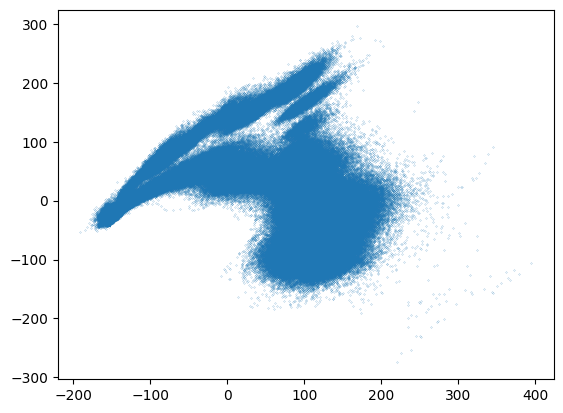

In [47]:
plt.scatter(x=principalComponents[:, 0], y=principalComponents[:, 1],s=0.02)

In [54]:
import sklearn.cluster as cluster
kmeans_labels = cluster.KMeans(n_clusters=3).fit_predict(df_all.T)

In [ ]:
import hdbscan
clusterer = hdbscan.HDBSCAN(metric='euclidean')
clusterer.fit(df_all.T)

ValueError: 'c' argument has 64 elements, which is inconsistent with 'x' and 'y' with size 594410.

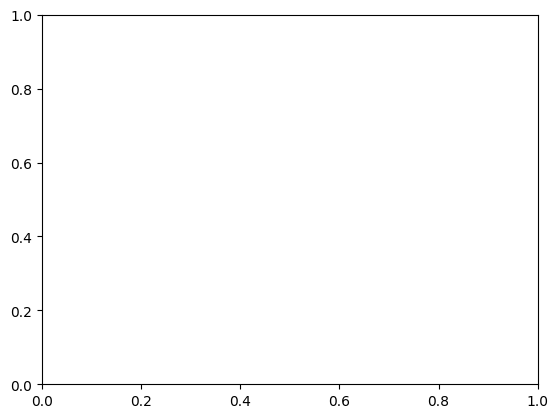

In [50]:
plt.scatter(x=principalComponents[:, 1], y=principalComponents[:, 2],s=0.02,c=clusterer.labels_)

In [56]:
n = principalComponents.shape[1]
order = 1 
plt.figure(figsize=(16,10))
for i in range(n):
    for j in range(n):
        plt.subplot(n, n, order)
        plt.scatter(x=principalComponents[:, i], y=principalComponents[:, j], s = 0.02,c=kmeans_labels)
        
        if j == 0:
            plt.ylabel("PCA " + str(i))
            
        if i == n-1:
            plt.xlabel("PCA " + str(j))
        
        order += 1

plt.savefig(path+'/pcaa_plot_'+date+'.png', bbox_inches='tight')  # Save as PNG
#plt.savefig("umap_plot.pdf", dpi=300, bbox_inches='tight')  # Save as PDF (optional)

plt.show()  # Display the plot (optional)

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f63c75ed800> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [36]:
print('start UMAP plotting')
mapper = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2).fit(df_all.T)

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu10/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


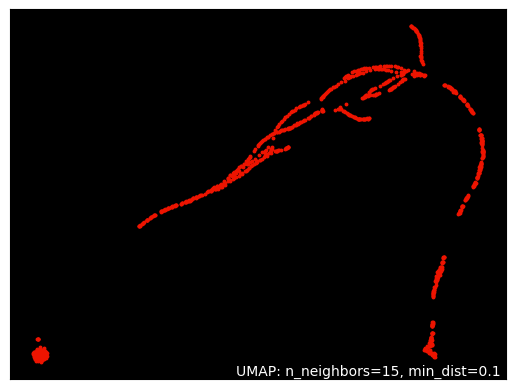

In [38]:
# Assuming 'mapper' is your UMAP model
fig, ax = plt.subplots()
umap.plot.points(mapper, theme='fire', ax=ax)

# Save the figure
plt.savefig(path+'/umap_plot_'+date+'.png', bbox_inches='tight')  # Save as PNG
#plt.savefig("umap_plot.pdf", dpi=300, bbox_inches='tight')  # Save as PDF (optional)

plt.show()  # Display the plot (optional)